In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error,root_mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [3]:
from pathlib import Path

In [4]:
project_dir = Path()

In [5]:
file_path = project_dir/'Data/Energy_Prices.csv'

In [6]:
df= pd.read_csv(file_path)

In [7]:
df['stateDescription'].unique()

array(['Wyoming', 'New England', 'South Carolina', 'South Dakota',
       'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington',
       'West Virginia', 'Wisconsin', 'Alabama', 'Louisiana', 'Maine',
       'Maryland', 'Massachusetts', 'Michigan', 'Minnesota',
       'Mississippi', 'Middle Atlantic', 'Pacific Contiguous',
       'Pacific Noncontiguous', 'U.S. Total', 'Missouri', 'Montana',
       'Nebraska', 'Nevada', 'New Hampshire', 'New Jersey', 'New Mexico',
       'New York', 'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma',
       'Oregon', 'Rhode Island', 'Alaska', 'Arizona', 'Georgia', 'Hawaii',
       'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky',
       'Arkansas', 'California', 'Colorado', 'Connecticut', 'Delaware',
       'District of Columbia', 'Florida', 'East North Central',
       'West North Central', 'South Atlantic', 'East South Central',
       'West South Central', 'Mountain', 'Pennsylvania'], dtype=object)

In [8]:
df['Date']=pd.to_datetime(dict(year=df['year'],
                               month=df['month'],
                               day=1))

In [9]:
df_new = df[(df['stateDescription']=='California') & (df['sectorName']=='residential')]

In [10]:
df_new.sort_values(by='Date',inplace=True)

C:\Users\Shaaf\AppData\Local\Temp\ipykernel_14344\1937125586.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new.sort_values(by='Date',inplace=True)


In [11]:
df_new.set_index('Date',inplace=True)

In [12]:
df_new

,year,month,stateDescription,sectorName,customers,price,revenue,sales
Date,,,,,,,,
2001-01-01,2001,1,California,residential,NaN,10.89,788.00660,7235.93425
2001-02-01,2001,2,California,residential,NaN,11.14,682.68637,6126.17336
2001-03-01,2001,3,California,residential,NaN,11.29,737.20165,6527.29022
2001-04-01,2001,4,California,residential,NaN,11.14,601.33405,5395.78333
2001-05-01,2001,5,California,residential,NaN,11.97,663.12406,5541.02829
...,...,...,...,...,...,...,...,...
2023-09-01,2023,9,California,residential,13815260.0,29.99,2376.17778,7923.89607
2023-10-01,2023,10,California,residential,14050712.0,26.73,1613.46437,6037.12300
2023-11-01,2023,11,California,residential,13797722.0,29.41,1830.47811,6224.35700


In [13]:
print(pd.infer_freq(df['Date']))

None


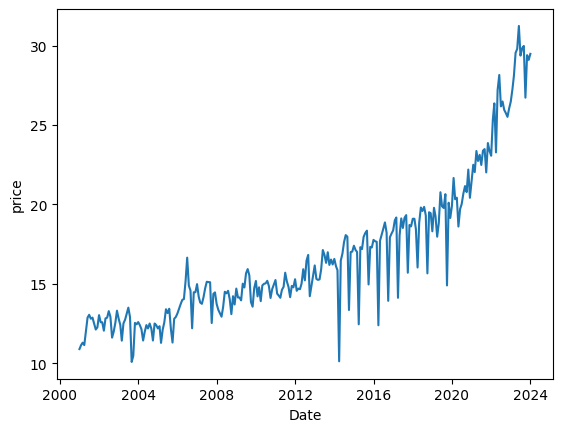

In [14]:
plt.Figure(figsize=(10,15))
sns.lineplot(df_new['price'])
plt.show()

In [15]:
results = seasonal_decompose(df_new['price'],model='multiplicative',period=12)

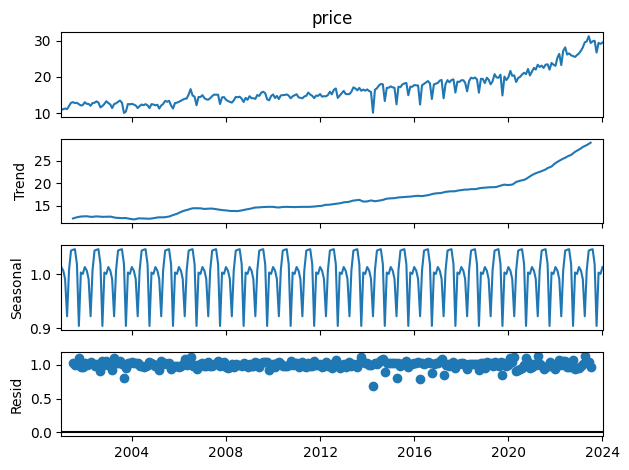

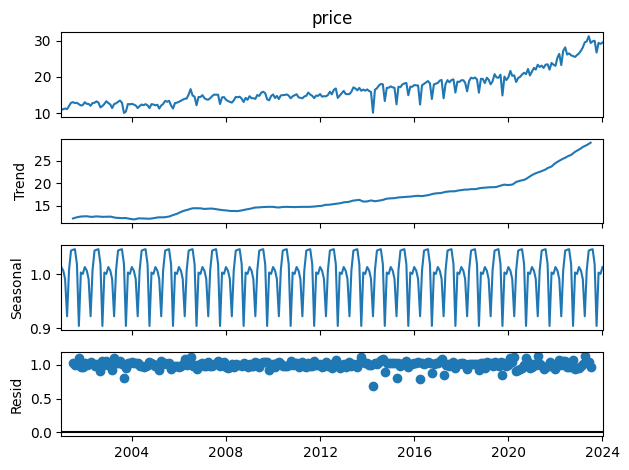

In [16]:
results.plot()

In [17]:
test = adfuller(df_new['price'])

In [18]:
test

(np.float64(5.161882454192107),
 1.0,
 12,
 264,
 {'1%': np.float64(-3.455365238788105),
  '5%': np.float64(-2.8725510317187024),
  '10%': np.float64(-2.5726375763314966)},
 np.float64(712.9252472898418))

In [20]:
# model = auto_arima()

In [22]:
tsa_data = df_new['price']

In [23]:
tsa_data

Date
2001-01-01    10.89
2001-02-01    11.14
2001-03-01    11.29
2001-04-01    11.14
2001-05-01    11.97
              ...  
2023-09-01    29.99
2023-10-01    26.73
2023-11-01    29.41
2023-12-01    29.11
2024-01-01    29.49
Name: price, Length: 277, dtype: float64

In [24]:
tsa_data = pd.DataFrame(tsa_data)

In [25]:
split_idx = int((len(df_new))*0.8)
y_train = tsa_data.iloc[:split_idx]
y_test = tsa_data.iloc[split_idx:]

In [26]:
# pmd_model = auto_arima(
#     y_train,
#     seasonal=True,
#     trace=True,
#     stepwise=True,
#     m=12
# )

In [28]:
best_order = (2,1,3)
best_seasonal_order = (2,0,0,12)

In [29]:
arima_model = ARIMA(y_train,order=best_order)
arima_results=arima_model.fit()

c:\Users\Shaaf\Desktop\Data Science\Practice Projects\DeepLearning\Energy Predictions\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Shaaf\Desktop\Data Science\Practice Projects\DeepLearning\Energy Predictions\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Shaaf\Desktop\Data Science\Practice Projects\DeepLearning\Energy Predictions\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [30]:
arima_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  price   No. Observations:                  221
Model:                 ARIMA(2, 1, 3)   Log Likelihood                -336.994
Date:                Mon, 22 Jun 2026   AIC                            685.988
Time:                        14:25:04   BIC                            706.349
Sample:                    01-01-2001   HQIC                           694.210
                         - 05-01-2019                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.1577      0.073    -15.798      0.000      -1.301      -1.014
ar.L2         -0.7199      0.067    -10.787      0.000      -0.851      -0.589
ma.L1          0.5544      0.058      9.543      0.000       0.441       0.668
ma.L2         -0.3134      0.058     -5.395      0.000      -0.427      -0.200
ma.L3         -0.7768      0.045    -17.369      0.000      -0.864      -0.689
sigma2         1.2416      0.079     15.731      0.000       1.087       1.396
===================================================================================
Ljung-Box (L1) (Q):                   1.60   Jarque-Bera (JB):               412.45
Prob(Q):                              0.21   Prob(JB):                         0.00
Heteroskedasticity (H):               3.89   Skew:                            -1.54
Prob(H) (two-sided):                  0.00   Kurtosis:                         8.96
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [31]:
arima_results.fittedvalues

Date
2001-01-01     0.000000
2001-02-01    10.889993
2001-03-01    11.060180
2001-04-01    11.123345
2001-05-01    11.083704
                ...    
2019-01-01    18.607068
2019-02-01    18.124045
2019-03-01    19.733077
2019-04-01    18.254490
2019-05-01    18.541557
Length: 221, dtype: float64

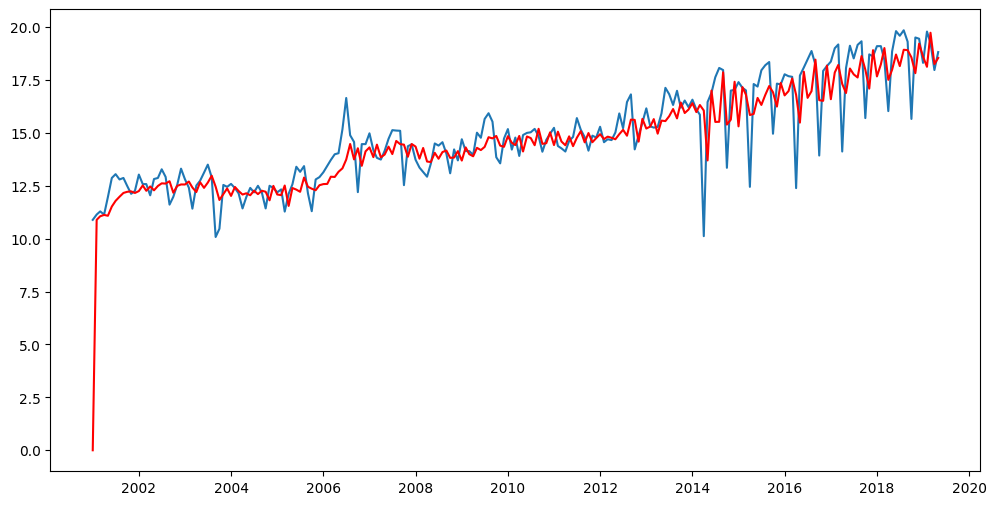

In [32]:
plt.figure(figsize=(12,6))
plt.plot(y_train,label='Actual')
plt.plot(arima_results.fittedvalues, color='red')

In [33]:
sarima_model = SARIMAX(y_train,order=best_order,seasonal_order=best_seasonal_order)
sarima_model=sarima_model.fit()

c:\Users\Shaaf\Desktop\Data Science\Practice Projects\DeepLearning\Energy Predictions\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Shaaf\Desktop\Data Science\Practice Projects\DeepLearning\Energy Predictions\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


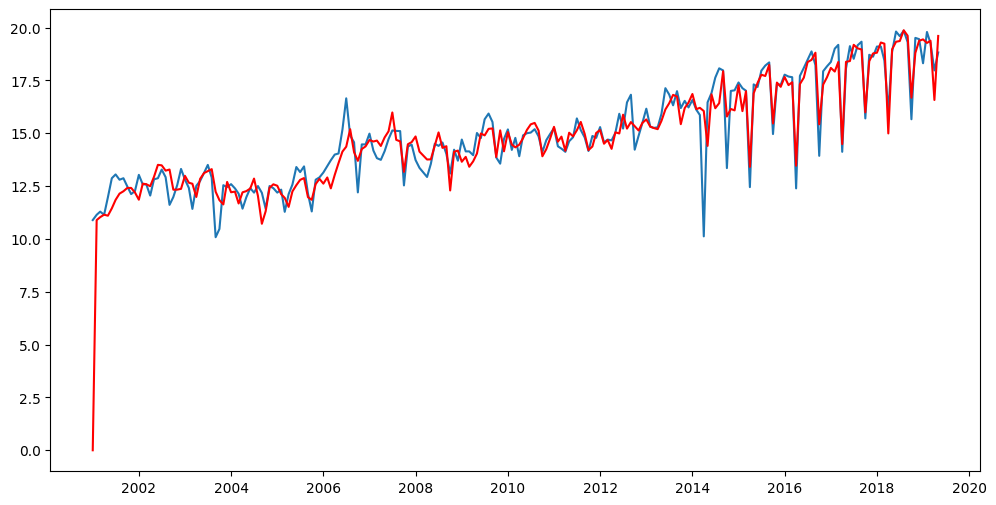

In [34]:
plt.figure(figsize=(12,6))
plt.plot(y_train,label='Actual')
plt.plot(sarima_model.fittedvalues, color='red')

In [35]:
predicted_sarimax = sarima_model.forecast(steps=len(y_test))

In [36]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)
import numpy as np
mae = mean_absolute_error(y_test, predicted_sarimax )
rmse = np.sqrt(mean_squared_error(y_test,predicted_sarimax ))

print(f"mae{mae}")
print(f"rmse{rmse}")

mae4.112488258859502
rmse5.127667268024293


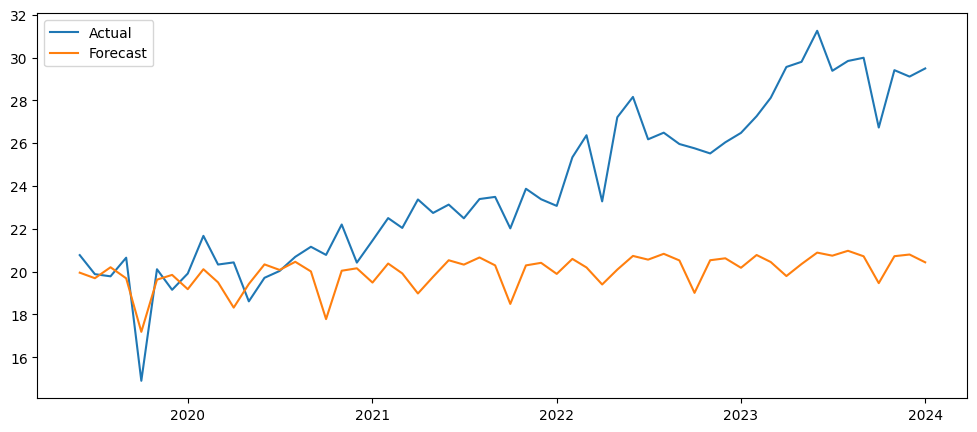

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(y_test.index,
         y_test,
         label='Actual')

plt.plot(y_test.index,
         predicted_sarimax,
         label='Forecast')

plt.legend()
plt.show()

In [38]:
predicted_values = pd.DataFrame(predicted_sarimax)

In [39]:
new_data = y_test.copy()

In [40]:
new_data.head()

,price
Date,
2019-06-01,20.77
2019-07-01,19.88
2019-08-01,19.78
2019-09-01,20.65
2019-10-01,14.90


In [41]:
new_data['forecast_price']= predicted_values

In [42]:
new_data['residulas']= new_data['price']- new_data['forecast_price']

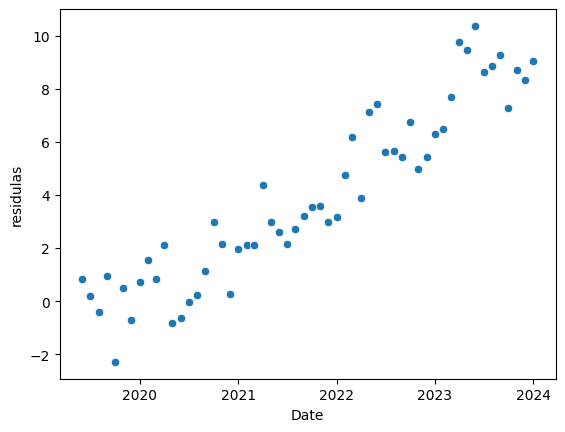

In [43]:
sns.scatterplot(new_data['residulas'])
plt.show()

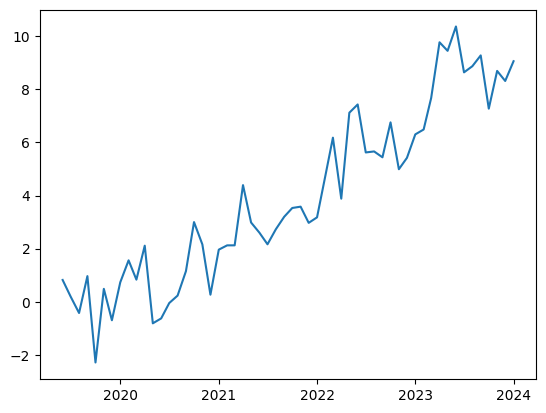

In [44]:
plt.plot(new_data['residulas'])

In [45]:
df_new

,year,month,stateDescription,sectorName,customers,price,revenue,sales
Date,,,,,,,,
2001-01-01,2001,1,California,residential,NaN,10.89,788.00660,7235.93425
2001-02-01,2001,2,California,residential,NaN,11.14,682.68637,6126.17336
2001-03-01,2001,3,California,residential,NaN,11.29,737.20165,6527.29022
2001-04-01,2001,4,California,residential,NaN,11.14,601.33405,5395.78333
2001-05-01,2001,5,California,residential,NaN,11.97,663.12406,5541.02829
...,...,...,...,...,...,...,...,...
2023-09-01,2023,9,California,residential,13815260.0,29.99,2376.17778,7923.89607
2023-10-01,2023,10,California,residential,14050712.0,26.73,1613.46437,6037.12300
2023-11-01,2023,11,California,residential,13797722.0,29.41,1830.47811,6224.35700


In [47]:
corr_Data = df_new.select_dtypes('number')

In [48]:
corr_Data

,year,month,customers,price,revenue,sales
Date,,,,,,
2001-01-01,2001,1,NaN,10.89,788.00660,7235.93425
2001-02-01,2001,2,NaN,11.14,682.68637,6126.17336
2001-03-01,2001,3,NaN,11.29,737.20165,6527.29022
2001-04-01,2001,4,NaN,11.14,601.33405,5395.78333
2001-05-01,2001,5,NaN,11.97,663.12406,5541.02829
...,...,...,...,...,...,...
2023-09-01,2023,9,13815260.0,29.99,2376.17778,7923.89607
2023-10-01,2023,10,14050712.0,26.73,1613.46437,6037.12300
2023-11-01,2023,11,13797722.0,29.41,1830.47811,6224.35700


<Axes: >

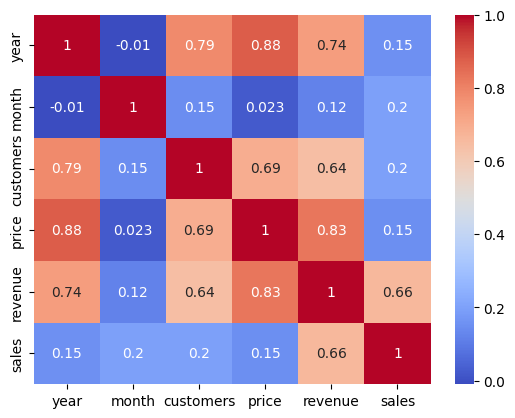

In [49]:
sns.heatmap(corr_Data.corr(), cmap='coolwarm',annot=True)

In [52]:
project_dir = Path().resolve()
data_dir = project_dir/"Data"
backup_file = list(data_dir.glob("Backup_file*.csv"))

In [56]:
backup_file

[WindowsPath('C:/Users/Shaaf/Desktop/Data Science/Practice Projects/DeepLearning/Energy Predictions/Data/Backup_file-20260606.csv')]

In [55]:
backup_file[0]

WindowsPath('C:/Users/Shaaf/Desktop/Data Science/Practice Projects/DeepLearning/Energy Predictions/Data/Backup_file-20260606.csv')

In [57]:
df=pd.read_csv(backup_file[0])